Support Vectors, Weight, Bias & Norm (Part A)

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

The code X, y = make_blobs(...) generates synthetic data:

make_blobs: Creates clusters of data points.
n_samples=100, centers=2: Produces 100 points in 2 distinct clusters.
random_state=6, cluster_std=1.0: Ensures reproducibility and controls cluster spread.
X: Holds feature coordinates; y: Contains corresponding class labels.
Use: Creates a simple, linearly separable dataset to easily understand algorithms like SVMs.

In [2]:
# Generate linearly separable dataset
X, y = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=1.0)

Here's a concise explanation of the train_test_split code:

train_test_split: Divides the dataset into training and testing sets.
X, y: The features and labels being split.
test_size=0.2: Designates 20% of data for testing, 80% for training.
random_state=42: Ensures the split is reproducible every time.
Use: Prevents overfitting and provides an unbiased evaluation of model performance.


In [3]:
# Split data into train and test (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Here's a concise explanation of the SVM classifier code:

clf = svm.SVC(...): Initializes a Support Vector Classifier (SVC) model.
kernel='linear': Specifies a linear kernel, meaning it will try to find a straight line (hyperplane) to separate the data.
SVC: A powerful classification algorithm, effective in high-dimensional spaces.
Purpose: To create a model capable of classifying the linearly separable data.
Next Step: This clf object will now be trained on your data.

In [4]:
# Create Linear SVM classifier
clf = svm.SVC(kernel='linear')

In [5]:
# Train the classifier
clf.fit(X_train, y_train)

SVC(kernel='linear')

In [6]:
# ===============================
# (a) SUPPORT VECTORS
# ===============================

# Get support vectors
support_vectors = clf.support_vectors_

print("Support Vectors:\n", support_vectors)

Support Vectors:
 [[ 7.27059007 -4.84225716]
 [ 5.94013686 -7.80312963]
 [ 7.79476398 -8.06641415]]


In [8]:
# ===============================
# (b) WEIGHT VECTOR, BIAS & NORM
# ===============================

# Weight vector (w)
w = clf.coef_[0]

# Bias (b)
b = clf.intercept_[0]

# Norm of weight vector
w_norm = np.linalg.norm(w)

In [9]:
print("\nWeight Vector (w):", w)
print("Bias (b):", b)
print("Norm of Weight Vector ||w||:", w_norm)


Weight Vector (w): [-0.0903189  -0.63500074]
Bias (b): -3.4182718248728996
Norm of Weight Vector ||w||: 0.6413918004916654


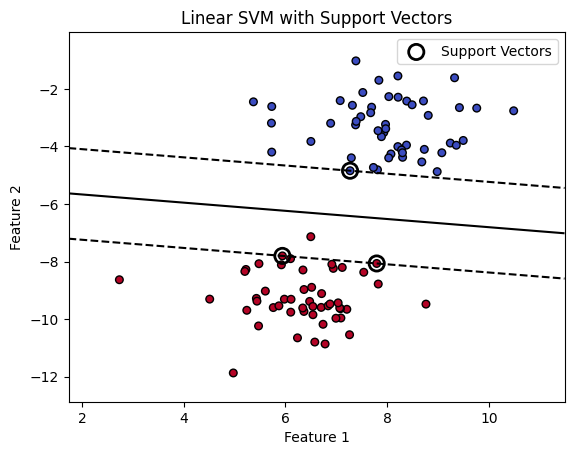

In [10]:
# ===============================
# PLOTTING DECISION BOUNDARY
# ===============================

# Create mesh grid
xx = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
yy = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=30, edgecolors='k')

# Plot decision boundary and margins
plt.contour(
    XX, YY, Z,
    colors='k',
    levels=[-1, 0, 1],
    linestyles=['--', '-', '--']
)

# Highlight support vectors
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=120,
    facecolors='none',
    edgecolors='k',
    linewidths=2,
    label='Support Vectors'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear SVM with Support Vectors")
plt.legend()
plt.show()

In [11]:
# ===============================
# MODEL ACCURACY
# ===============================
print("Accuracy:", clf.score(X_test, y_test) * 100, "%")

Accuracy: 100.0 %
